# MDR-TS v12.5
**Temporal-Station Soil Moisture Model + Shallow NN Baseline**

**Author:** Jakob Balkovec
**Affiliation:** Seattle University, Computer Science
**Project:** MDR
**Notebook Type:** Training, Evaluation, Baseline Modeling
**Last Updated:** Sat Feb 14th 2026

---

## Model Summary

- **Model Name:** MDR-TS
- **Version:** v12.5
- **Task:** Regression (Soil Moisture at 5 cm depth)
- **Target Variable:** `soil_moisture_5cm`
- **Temporal Resolution:** Daily

This notebook implements a clean baseline neural model:

1. **Shallow NN Baseline**
   A 2 to 3 layer mlp trained on the derived_new feature set with proper scaling, early stopping, and full evaluation.

Later notebooks may extend this with physics-residual correction and rain-focused modeling, but this notebook must remain a baseline.

---

## Reproducibility

- **Random Seed:** 42
- **Split Directory:** `data/splits/derived_new/`
- **Environment:** MacBook M2 Pro (local kernel)

---

## What’s New

- Adding a layer of physics to better model the wet regime


## 1. Imports + Environment Setup

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"using device: {device}")


using device: cpu


## 2. Features

In [2]:
split_dir = Path("/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new")
train_path = split_dir / "train_derived_new.csv"
val_path = split_dir / "val_derived_new.csv"
test_path = split_dir / "test_derived_new.csv"
meta_path = split_dir / "split_meta.json"

for p in [train_path, val_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"missing split file: {p}")

if meta_path.exists():
    print(f"found optional metadata: {meta_path}")
else:
    print("optional split_meta.json not found; continuing without it")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

target_col = "soil_moisture_5cm"
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if target_col not in df.columns:
        raise ValueError(f"{target_col} missing in {name} split")

train_df = train_df.dropna(subset=[target_col]).copy()
val_df = val_df.dropna(subset=[target_col]).copy()
test_df = test_df.dropna(subset=[target_col]).copy()

exclude_cols = {
    target_col, "split", "fold", "station_id", "date", "timestamp", "path", "id"
}

# drop obvious index junk
for df in [train_df, val_df, test_df]:
    junk = [c for c in df.columns if c.lower().startswith("unnamed")]
    if junk:
        df.drop(columns=junk, inplace=True)

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

if not feature_cols:
    raise ValueError("no numeric feature columns were inferred")

# enforce shared feature set across splits (prevents one-off column failures)
shared = set(feature_cols) & set(val_df.columns) & set(test_df.columns)
dropped = [c for c in feature_cols if c not in shared]
feature_cols = sorted(list(shared))

if not feature_cols:
    raise ValueError("no shared feature columns across train/val/test")

if dropped:
    print(f"dropped {len(dropped)} train-only numeric feature cols (not in all splits)")

# coerce to numeric first, then compute medians on train only
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

train_medians = train_df[feature_cols].median()
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].fillna(train_medians)

print(f"train rows: {len(train_df):,} | val rows: {len(val_df):,} | test rows: {len(test_df):,}")
print(f"features: {len(feature_cols)}")

optional split_meta.json not found; continuing without it
train rows: 16,972 | val rows: 2,919 | test rows: 2,829
features: 353


In [3]:
def is_rain_feature(c: str) -> bool:
    s = c.lower()
    return ("rain" in s) or ("api" in s) or ("precip" in s) or ("ppt" in s)

rain_cols = [c for c in feature_cols if is_rain_feature(c)]
soil_cols = [c for c in feature_cols if c not in rain_cols]

if len(rain_cols) == 0:
    print("warning: no rain-like columns found; rain branch will be weak")
print(f"rain features: {len(rain_cols)} | soil features: {len(soil_cols)}")

rain features: 43 | soil features: 310


## 3. Masking

In [4]:
gate_col = None
for c in ["G_rain_sum_7d", "G_API", "G_rain_sum_3d"]:
    if c in train_df.columns:
        gate_col = c
        break

wet_masks = None
wet_threshold = None

if gate_col is None:
    print("wet/dry reporting skipped: no gate column found")
else:
    # ensure numeric + handle inf
    for df in [train_df, val_df, test_df]:
        df[gate_col] = pd.to_numeric(df[gate_col], errors="coerce")
        df[gate_col] = df[gate_col].replace([np.inf, -np.inf], np.nan)

    if train_df[gate_col].isna().all():
        print(f"wet/dry skipped: {gate_col} is entirely NaN in train")
    else:
        wet_threshold = float(train_df[gate_col].quantile(0.90))

        wet_masks = {
            "train": (train_df[gate_col].to_numpy() >= wet_threshold),
            "val": (val_df[gate_col].to_numpy() >= wet_threshold),
            "test": (test_df[gate_col].to_numpy() >= wet_threshold),
        }

        print(f"wet/dry gate column: {gate_col}")
        print(f"wet threshold (train q0.90): {wet_threshold:.6f}")

wet/dry gate column: G_rain_sum_7d
wet threshold (train q0.90): 92.500000


## 4. Scaling + Data Loaders

In [5]:
X_soil_train = train_df[soil_cols].to_numpy(dtype=np.float32)
X_soil_val = val_df[soil_cols].to_numpy(dtype=np.float32)
X_soil_test = test_df[soil_cols].to_numpy(dtype=np.float32)

X_rain_train = train_df[rain_cols].to_numpy(dtype=np.float32) if len(rain_cols) else np.zeros((len(train_df), 1), dtype=np.float32)
X_rain_val = val_df[rain_cols].to_numpy(dtype=np.float32) if len(rain_cols) else np.zeros((len(val_df), 1), dtype=np.float32)
X_rain_test = test_df[rain_cols].to_numpy(dtype=np.float32) if len(rain_cols) else np.zeros((len(test_df), 1), dtype=np.float32)

y_train = train_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)
y_val = val_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)
y_test = test_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

for X_name, X in [
    ("soil_train", X_soil_train), ("soil_val", X_soil_val), ("soil_test", X_soil_test),
    ("rain_train", X_rain_train), ("rain_val", X_rain_val), ("rain_test", X_rain_test),
]:
    if not np.isfinite(X).all():
        raise ValueError(f"non-finite values found in X_{X_name}")

for y_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    if not np.isfinite(y).all():
        raise ValueError(f"non-finite values found in y_{y_name}")

In [6]:
soil_scaler = StandardScaler()
X_soil_train_s = soil_scaler.fit_transform(X_soil_train).astype(np.float32)
X_soil_val_s = soil_scaler.transform(X_soil_val).astype(np.float32)
X_soil_test_s = soil_scaler.transform(X_soil_test).astype(np.float32)

rain_scaler = StandardScaler()
X_rain_train_s = rain_scaler.fit_transform(X_rain_train).astype(np.float32)
X_rain_val_s = rain_scaler.transform(X_rain_val).astype(np.float32)
X_rain_test_s = rain_scaler.transform(X_rain_test).astype(np.float32)

In [7]:
X_soil_train_t = torch.from_numpy(X_soil_train_s)
X_soil_val_t = torch.from_numpy(X_soil_val_s)
X_soil_test_t = torch.from_numpy(X_soil_test_s)

X_rain_train_t = torch.from_numpy(X_rain_train_s)
X_rain_val_t = torch.from_numpy(X_rain_val_s)
X_rain_test_t = torch.from_numpy(X_rain_test_s)

y_train_t = torch.from_numpy(y_train)
y_val_t = torch.from_numpy(y_val)
y_test_t = torch.from_numpy(y_test)

train_ds = TensorDataset(X_soil_train_t, X_rain_train_t, y_train_t)
val_ds = TensorDataset(X_soil_val_t, X_rain_val_t, y_val_t)
test_ds = TensorDataset(X_soil_test_t, X_rain_test_t, y_test_t)

batch_size = 1024 if len(train_ds) >= 50000 else 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"batch size: {batch_size}")
print(f"soil dims: {X_soil_train_t.shape[1]} | rain dims: {X_rain_train_t.shape[1]}")

batch size: 512
soil dims: 310 | rain dims: 43


## 5. Model

In [8]:
soil_h1 = 256
soil_h2 = 128
rain_h1 = 64
rain_h2 = 32
dropout_p = 0.1
log_var_min = -10.0
log_var_max = 6.0
eps = 1e-6

class DualBranchGaussianNLL(nn.Module):
    def __init__(self, soil_dim: int, rain_dim: int):
        super().__init__()

        self.soil_net = nn.Sequential(
            nn.Linear(soil_dim, soil_h1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(soil_h1, soil_h2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        # physics: learn a saturating forcing scalar from rain features
        self.rain_feat = nn.Sequential(
            nn.Linear(rain_dim, rain_h1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(rain_h1, rain_h2),
            nn.ReLU(),
        )
        self.rain_force = nn.Linear(rain_h2, 1)

        # output heads
        self.head_mu = nn.Linear(soil_h2 + 1, 1)
        self.head_log_var = nn.Linear(soil_h2 + 1, 1)

        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x_soil, x_rain):
        h_soil = self.soil_net(x_soil)

        h_rain = self.rain_feat(x_rain)
        raw_force = self.rain_force(h_rain)

        # physics: nonnegative + saturating forcing term
        force_pos = torch.nn.functional.softplus(raw_force)
        force_sat = 1.0 - torch.exp(-force_pos)

        h = torch.cat([h_soil, force_sat], dim=1)

        mu = self.head_mu(h)
        log_var = self.head_log_var(h)
        log_var = torch.clamp(log_var, min=log_var_min, max=log_var_max)
        return mu, log_var, force_sat

model = DualBranchGaussianNLL(soil_dim=X_soil_train_t.shape[1], rain_dim=X_rain_train_t.shape[1]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

DualBranchGaussianNLL(
  (soil_net): Sequential(
    (0): Linear(in_features=310, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (rain_feat): Sequential(
    (0): Linear(in_features=43, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  )
  (rain_force): Linear(in_features=32, out_features=1, bias=True)
  (head_mu): Linear(in_features=129, out_features=1, bias=True)
  (head_log_var): Linear(in_features=129, out_features=1, bias=True)
)


## 6. Training Loop + Early Stopping

In [9]:
def safe_r2(y_true, y_pred):
    if y_true.size == 0:
        return np.nan
    if np.allclose(y_true, y_true[0]):
        return np.nan
    return float(r2_score(y_true, y_pred))

In [10]:
def gaussian_nll(mu, log_var, target):
    err2 = (target - mu) ** 2
    inv_var = torch.exp(-log_var)
    return torch.mean(0.5 * (inv_var * err2 + log_var))

In [11]:
def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    y_true_chunks = []
    y_pred_chunks = []

    for x_soil, x_rain, yb in loader:
        x_soil = x_soil.to(device)
        x_rain = x_rain.to(device)
        yb = yb.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            mu, log_var, force_sat = model(x_soil, x_rain)
            loss = gaussian_nll(mu, log_var, yb)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        y_true_chunks.append(yb.detach().cpu().numpy().reshape(-1))
        y_pred_chunks.append(mu.detach().cpu().numpy().reshape(-1))

    y_true_epoch = np.concatenate(y_true_chunks)
    y_pred_epoch = np.concatenate(y_pred_chunks)
    mean_loss = total_loss / len(loader.dataset)
    return mean_loss, y_true_epoch, y_pred_epoch

In [12]:
max_epochs = 200
patience = 15
wait = 0
best_val_r2 = -np.inf
best_state = None

epoch_bar = tqdm(range(1, max_epochs + 1), desc="training", leave=True)

for epoch in epoch_bar:
    train_loss, _, _ = run_epoch(train_loader, training=True)
    val_loss, y_val_true_epoch, y_val_pred_epoch = run_epoch(val_loader, training=False)

    val_r2 = safe_r2(y_val_true_epoch, y_val_pred_epoch)
    val_mae = float(mean_absolute_error(y_val_true_epoch, y_val_pred_epoch))
    val_rmse = float(np.sqrt(mean_squared_error(y_val_true_epoch, y_val_pred_epoch)))

    improved = np.isnan(best_val_r2) or (
        not np.isnan(val_r2) and (val_r2 > best_val_r2 + 1e-6)
    )

    if improved:
        best_val_r2 = val_r2
        wait = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1

    epoch_bar.set_postfix(
        train_loss=f"{train_loss:.4f}",
        val_loss=f"{val_loss:.4f}",
        val_r2=f"{val_r2:.4f}",
        wait=wait,
    )

    if wait >= patience:
        print(f"early stopping at epoch {epoch}; best val_r2={best_val_r2:.6f}")
        break

if best_state is None:
    raise RuntimeError("training did not produce a valid checkpoint")

model.load_state_dict(best_state)
model.to(device)
print(f"restored best model with val_r2={best_val_r2:.6f}")

training:   0%|          | 0/200 [00:00<?, ?it/s]

early stopping at epoch 47; best val_r2=0.786477
restored best model with val_r2=0.786477


## 7. Evaluation

In [13]:
@torch.no_grad()
def predict_scaled(X_soil_scaled: np.ndarray, X_rain_scaled: np.ndarray, batch_size: int = 4096):
    model.eval()
    soil_t = torch.from_numpy(X_soil_scaled.astype(np.float32))
    rain_t = torch.from_numpy(X_rain_scaled.astype(np.float32))
    loader = DataLoader(TensorDataset(soil_t, rain_t), batch_size=batch_size, shuffle=False, num_workers=0)
    preds = []
    for xs, xr in loader:
        xs = xs.to(device)
        xr = xr.to(device)
        mu, log_var, force_sat = model(xs, xr)
        preds.append(mu.detach().cpu().numpy().reshape(-1))
    return np.concatenate(preds)

In [14]:
@torch.no_grad()
def predict_mu_sigma_scaled(X_scaled: np.ndarray, batch_size: int = 4096):
    model.eval()
    x_tensor = torch.from_numpy(X_scaled.astype(np.float32))
    loader = DataLoader(x_tensor, batch_size=batch_size, shuffle=False, num_workers=0)
    mus = []
    sigmas = []
    for xb in loader:
        xb = xb.to(device)
        mu, log_var = model(xb)
        mus.append(mu.detach().cpu().numpy().reshape(-1))
        sigmas.append(np.sqrt(np.exp(log_var.detach().cpu().numpy().reshape(-1))))
    return np.concatenate(mus), np.concatenate(sigmas)

In [15]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if y_true.size == 0:
        return {"r2": np.nan, "mae": np.nan, "rmse": np.nan, "bias": np.nan, "medae": np.nan, "pearson": np.nan}

    r2 = safe_r2(y_true, y_pred)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    err = y_pred - y_true
    bias = float(np.mean(err))
    medae = float(np.median(np.abs(err)))

    y_true_c = y_true - np.mean(y_true)
    y_pred_c = y_pred - np.mean(y_pred)
    denom = float(np.sqrt(np.sum(y_true_c ** 2)) * np.sqrt(np.sum(y_pred_c ** 2)))
    pearson = float(np.sum(y_true_c * y_pred_c) / denom) if denom > 0 else np.nan

    return {"r2": r2, "mae": mae, "rmse": rmse, "bias": bias, "medae": medae, "pearson": pearson}

In [16]:
y_train_pred = predict_scaled(X_soil_train_s, X_rain_train_s)
y_val_pred = predict_scaled(X_soil_val_s, X_rain_val_s)
y_test_pred = predict_scaled(X_soil_test_s, X_rain_test_s)

y_train_true = y_train.reshape(-1)
y_val_true = y_val.reshape(-1)
y_test_true = y_test.reshape(-1)

metrics = {
    "train": {"overall": compute_metrics(y_train_true, y_train_pred)},
    "val": {"overall": compute_metrics(y_val_true, y_val_pred)},
    "test": {"overall": compute_metrics(y_test_true, y_test_pred)},
}

if wet_masks is not None:
    for split_name, y_true_split, y_pred_split in [
        ("train", y_train_true, y_train_pred),
        ("val", y_val_true, y_val_pred),
        ("test", y_test_true, y_test_pred),
    ]:
        mask_wet = wet_masks[split_name]
        mask_dry = ~mask_wet
        metrics[split_name]["wet"] = compute_metrics(y_true_split[mask_wet], y_pred_split[mask_wet])
        metrics[split_name]["dry"] = compute_metrics(y_true_split[mask_dry], y_pred_split[mask_dry])

In [17]:
test_abs_err = np.abs(y_test_true - y_test_pred)
k = max(1, int(np.ceil(0.10 * len(test_abs_err))))
worst_idx = np.argsort(test_abs_err)[-k:]
metrics["test"]["worst_decile"] = compute_metrics(y_test_true[worst_idx], y_test_pred[worst_idx])

rows = []
for split_name in ["train", "val", "test"]:
    for subset_name in ["overall", "wet", "dry", "worst_decile"]:
        if subset_name in metrics[split_name]:
            m = metrics[split_name][subset_name]
            rows.append(
                {
                    "split": split_name,
                    "subset": subset_name,
                    "r2": m["r2"],
                    "mae": m["mae"],
                    "rmse": m["rmse"],
                    "bias": m["bias"],
                    "medae": m["medae"],
                    "pearson": m["pearson"],
                }
            )

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

split       subset        r2      mae     rmse      bias    medae   pearson
train      overall  0.478320 0.030277 0.073856  0.000761 0.022696  0.759045
train          wet  0.753276 0.022229 0.029374  0.005704 0.018237  0.874372
train          dry  0.438468 0.031172 0.077236  0.000211 0.023291  0.742877
  val      overall  0.786477 0.035017 0.046540 -0.020882 0.027394  0.912037
  val          wet -0.029595 0.031962 0.042325 -0.017281 0.026679  0.548479
  val          dry  0.790587 0.035449 0.047107 -0.021392 0.027508  0.913988
 test      overall  0.673340 0.042050 0.053456 -0.012392 0.036439  0.834280
 test          wet -2.710989 0.049248 0.056570 -0.044944 0.050241  0.439734
 test          dry  0.679908 0.041073 0.053019 -0.007975 0.034585  0.834532
 test worst_decile -1.049976 0.110145 0.116323 -0.034777 0.094899 -0.073213


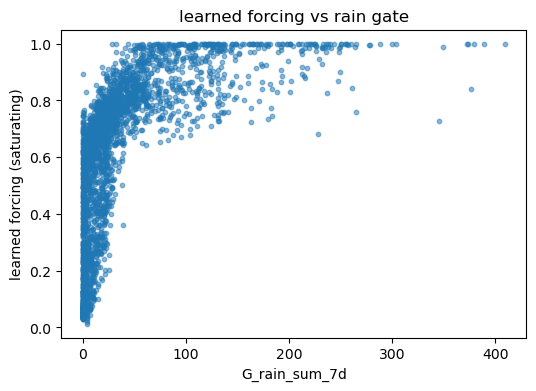

In [18]:
@torch.no_grad()
def predict_force(X_soil_scaled: np.ndarray, X_rain_scaled: np.ndarray, batch_size: int = 4096):
    model.eval()
    soil_t = torch.from_numpy(X_soil_scaled.astype(np.float32))
    rain_t = torch.from_numpy(X_rain_scaled.astype(np.float32))
    loader = DataLoader(TensorDataset(soil_t, rain_t), batch_size=batch_size, shuffle=False, num_workers=0)
    forces = []
    for xs, xr in loader:
        xs = xs.to(device)
        xr = xr.to(device)
        mu, log_var, force_sat = model(xs, xr)
        forces.append(force_sat.detach().cpu().numpy().reshape(-1))
    return np.concatenate(forces)

force_test = predict_force(X_soil_test_s, X_rain_test_s)

if gate_col is not None:
    gate_test = test_df[gate_col].to_numpy()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, force_test, s=10, alpha=0.5)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("learned forcing (saturating)")
    ax.set_title("learned forcing vs rain gate")
    plt.show()

In [19]:
artifact_dir = Path("/Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.5/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

pred_parts = []
for split_name, y_true_split, y_pred_split in [
    ("train", y_train_true, y_train_pred),
    ("val", y_val_true, y_val_pred),
    ("test", y_test_true, y_test_pred),
]:
    data = {
        "split": split_name,
        "y_true": y_true_split,
        "y_pred": y_pred_split,
        "abs_err": np.abs(y_true_split - y_pred_split),
    }
    if wet_masks is not None:
        data["is_wet"] = wet_masks[split_name].astype(int)
    pred_parts.append(pd.DataFrame(data))

preds_df = pd.concat(pred_parts, ignore_index=True)
preds_path = artifact_dir / "preds_mlp_v12_5.csv"
metrics_path = artifact_dir / "metrics_mlp_v12_5.json"

preds_df.to_csv(preds_path, index=False)
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"saved predictions: {preds_path}")
print(f"saved metrics: {metrics_path}")

saved predictions: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.5/artifacts/preds_mlp_v12_5.csv
saved metrics: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.5/artifacts/metrics_mlp_v12_5.json


## 8. Plots

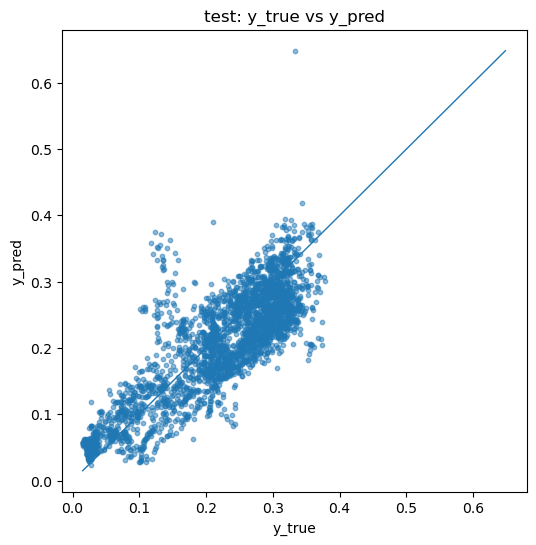

In [20]:
residuals_test = y_test_true - y_test_pred
abs_err_test = np.abs(residuals_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_true, y_test_pred, s=10, alpha=0.5)
min_v = float(min(y_test_true.min(), y_test_pred.min()))
max_v = float(max(y_test_true.max(), y_test_pred.max()))
ax.plot([min_v, max_v], [min_v, max_v], linewidth=1)
ax.set_xlabel("y_true")
ax.set_ylabel("y_pred")
ax.set_title("test: y_true vs y_pred")
plt.show()

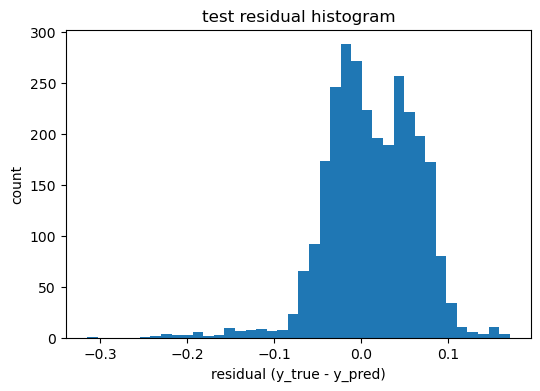

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals_test, bins=40)
ax.set_xlabel("residual (y_true - y_pred)")
ax.set_ylabel("count")
ax.set_title("test residual histogram")
plt.show()

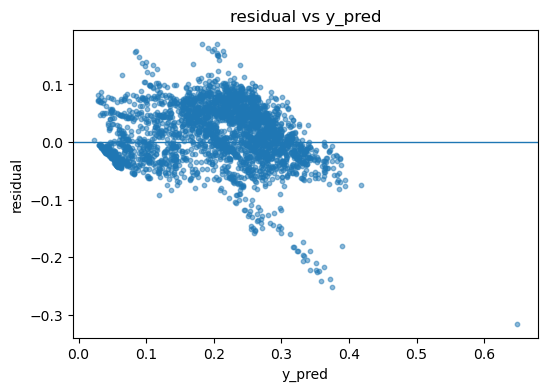

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test_pred, residuals_test, s=10, alpha=0.5)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("y_pred")
ax.set_ylabel("residual")
ax.set_title("residual vs y_pred")
plt.show()

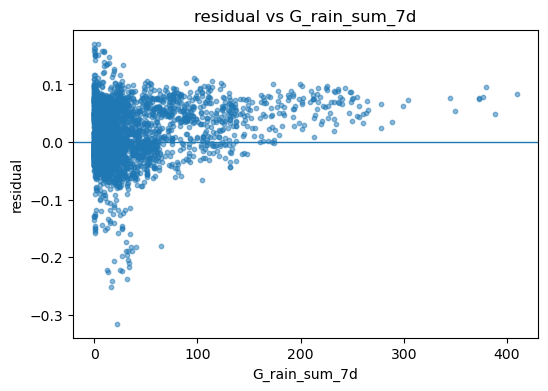

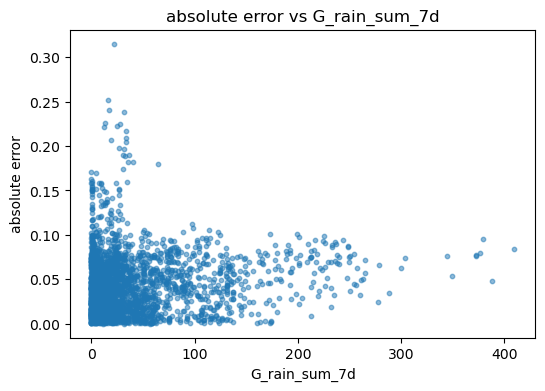

In [23]:
if gate_col is not None:
    gate_test = test_df[gate_col].to_numpy()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, residuals_test, s=10, alpha=0.5)
    ax.axhline(0.0, linewidth=1)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("residual")
    ax.set_title(f"residual vs {gate_col}")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, abs_err_test, s=10, alpha=0.5)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("absolute error")
    ax.set_title(f"absolute error vs {gate_col}")
    plt.show()

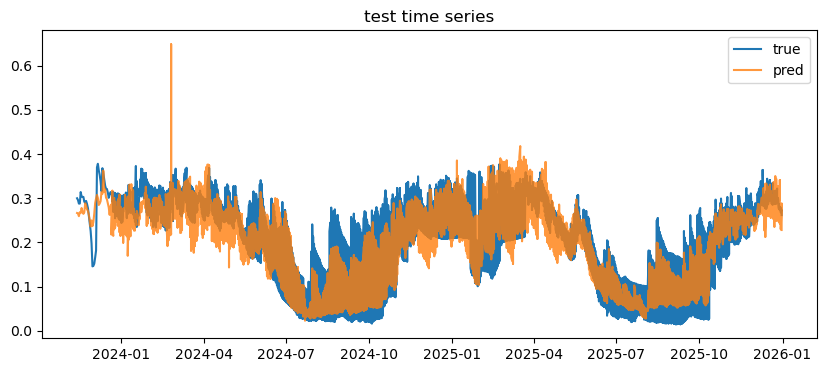

In [24]:
dates = pd.to_datetime(test_df["date"])
order = np.argsort(dates)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates.iloc[order], y_test_true[order], label="true")
ax.plot(dates.iloc[order], y_test_pred[order], label="pred", alpha=0.8)
ax.set_title("test time series")
ax.legend()
plt.show()